# Advanced Statistics & Regression: Ames Housing Dataset
## Estadística Avanzada y Regresión: Precios de Vivienda en Ames, Iowa

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** Ames Housing — house sale prices in Ames, Iowa (Kaggle)

**Objective / Objetivo:**  
EN · Perform advanced statistical analysis on housing data: normality tests, variance analysis, and VIF multicollinearity detection. Then build a linear regression model predicting `SalePrice` from `GrLivArea` and `2ndFlrSF`, validate all four regression assumptions, and interpret residuals.

ES · Realizar análisis estadístico avanzado sobre datos de vivienda: pruebas de normalidad, análisis de varianza y detección de multicolinealidad con VIF. Luego construir un modelo de regresión lineal que prediga `SalePrice` desde `GrLivArea` y `2ndFlrSF`, validar los cuatro supuestos de regresión e interpretar los residuales.

**Key findings / Hallazgos clave:**  
`SalePrice`: right-skewed, mean $180,921, std $79,442, outliers up to $755,000.  
Regression assumptions: mild heteroscedasticity detected at high price ranges.

**Techniques / Técnicas:** Normality tests · Variance · VIF · Linear Regression · Residual analysis · 4 regression assumptions  
**Libraries / Librerías:** `pandas` · `numpy` · `statsmodels` · `sklearn` · `scipy` · `seaborn` · `matplotlib`

---

# 0. Importar librerías y cargar datos

In [7]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.style as style
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

style.use('fivethirtyeight')

# Cargar datos
df = pd.read_csv('House Pricing.csv')

print(df.info())
print()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 1. Análisis Univariado: Distribución de Variables Numéricas

Se verificará la distribución de las variables `SalePrice`, `GrLivArea` y `2ndFlrSF` mediante:
- Métricas estadísticas: media, desviación estándar y cuartiles
- Visualizaciones: Histograma, QQ-Plot y Box Plot

## Estadísticas descriptivas de variables de interés

In [9]:
# Seleccionar variables de interés
variables = ['SalePrice', 'GrLivArea', '2ndFlrSF']

# Métricas estadísticas
print("=== Estadísticas Descriptivas ===")
print(df[variables].describe())

print("\n=== Media ===")
print(df[variables].mean())

print("\n=== Desviación Estándar ===")
print(df[variables].std())

print("\n=== Cuartiles ===")
print(df[variables].quantile([0.25, 0.50, 0.75]))

=== Estadísticas Descriptivas ===
           SalePrice    GrLivArea     2ndFlrSF
count    1460.000000  1460.000000  1460.000000
mean   180921.195890  1515.463699   346.992466
std     79442.502883   525.480383   436.528436
min     34900.000000   334.000000     0.000000
25%    129975.000000  1129.500000     0.000000
50%    163000.000000  1464.000000     0.000000
75%    214000.000000  1776.750000   728.000000
max    755000.000000  5642.000000  2065.000000

=== Media ===
SalePrice    180921.195890
GrLivArea      1515.463699
2ndFlrSF        346.992466
dtype: float64

=== Desviación Estándar ===
SalePrice    79442.502883
GrLivArea      525.480383
2ndFlrSF       436.528436
dtype: float64

=== Cuartiles ===
      SalePrice  GrLivArea  2ndFlrSF
0.25   129975.0    1129.50       0.0
0.50   163000.0    1464.00       0.0
0.75   214000.0    1776.75     728.0


## Función para visualizar distribución de variables

In [38]:
def plot_dist_char(df, feature):
    fig = plt.figure(constrained_layout=True, figsize=(15, 10))
    grid = gridspec.GridSpec(ncols=3, nrows=2, figure=fig)

    # Media y Desviación Estándar
    mu = np.mean(df[feature])
    sigma = np.std(df[feature])

    # Histograma
    ax1 = fig.add_subplot(grid[0, :2])
    ax1.set_title(f'Histogram - {feature}')
    sns.histplot(df[feature], kde=True, ax=ax1, label=f'Normal dist. ($\\mu$={mu:.2f}, $\\sigma$={sigma:.2f})')
    ax1.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Media: {mu:.2f}')
    ax1.legend(fontsize=11)

    # QQ Plot
    ax2 = fig.add_subplot(grid[1, :2])
    stats.probplot(df[feature].dropna(), plot=ax2)
    ax2.set_title(f'QQ Plot - {feature}')

    # Box Plot
    ax3 = fig.add_subplot(grid[:, 2])
    ax3.set_title(f'Box Plot - {feature}')
    sns.boxplot(y=df[feature], ax=ax3)
    mediana = df[feature].median()
    ax3.axhline(mediana, color='darkorange', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.0f}')
    ax3.legend(fontsize=10)

    plt.suptitle(f'Distribución de {feature}', fontsize=16, y=1.02)
    plt.show()

## Visualización de SalePrice

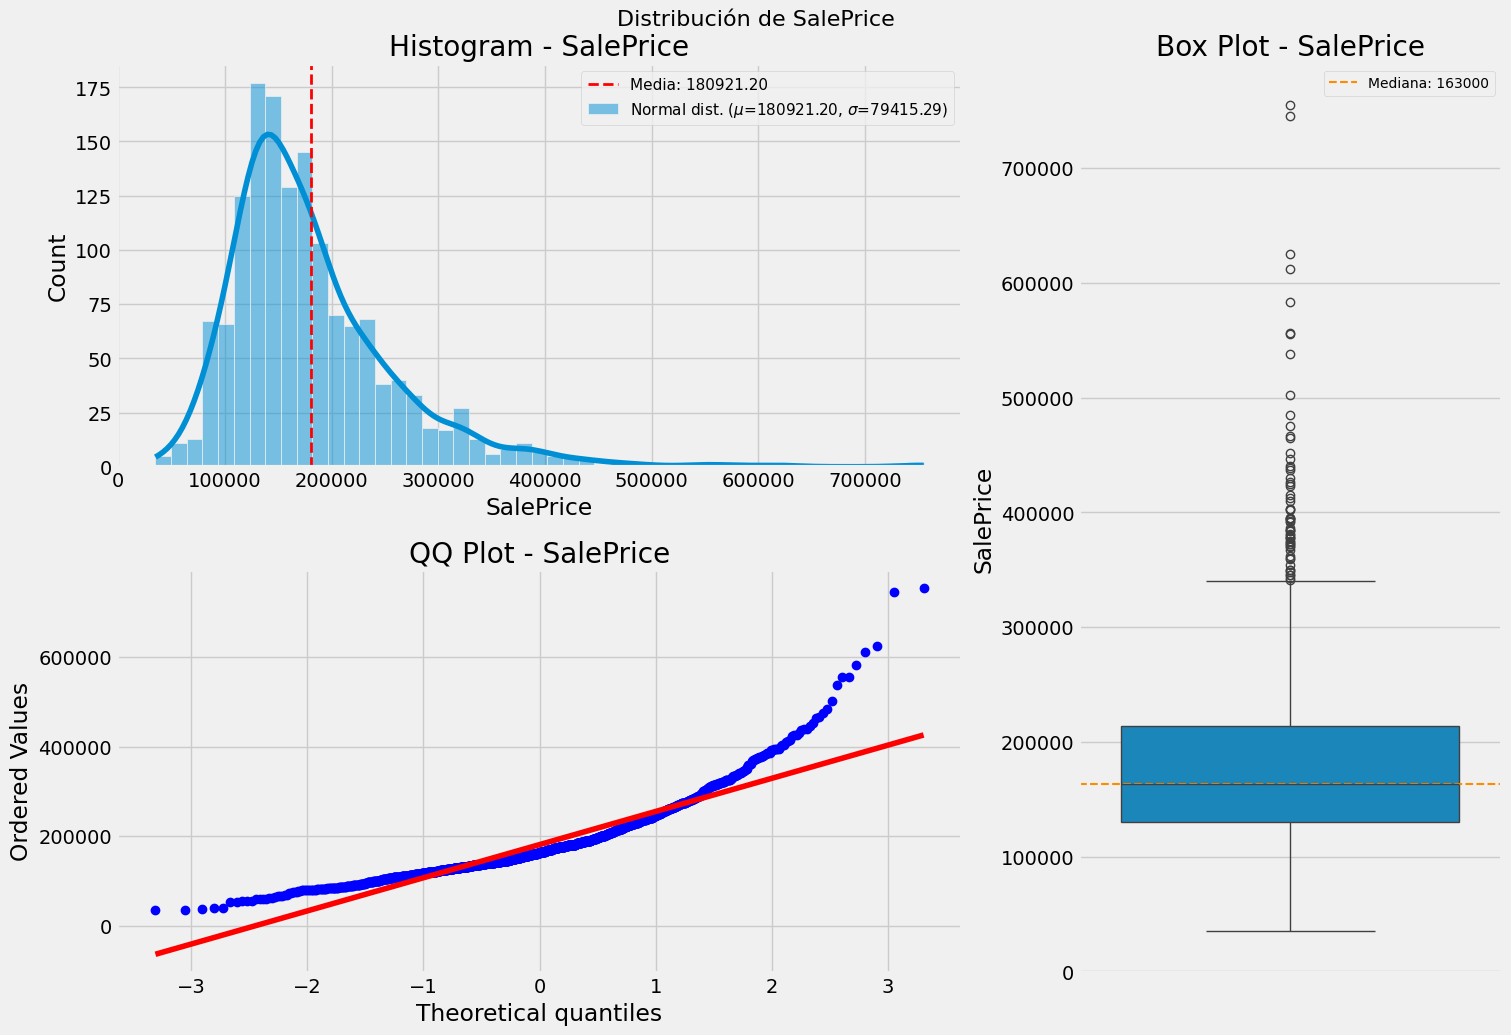

In [39]:
plot_dist_char(df, 'SalePrice')

## Visualización de GrLivArea

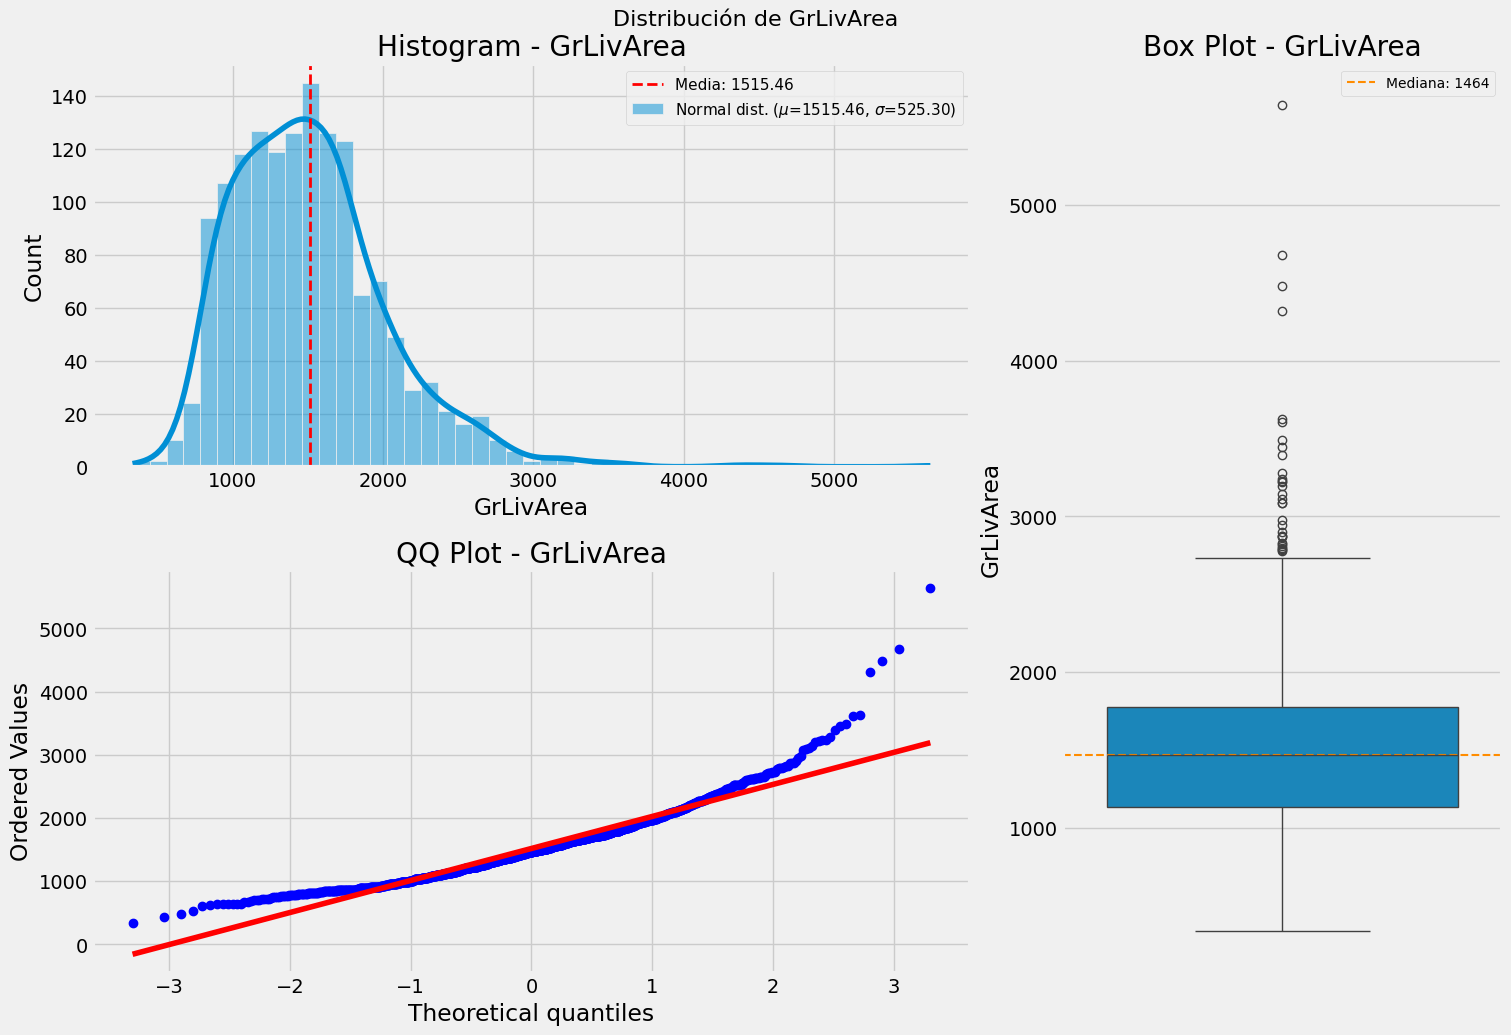

In [40]:
plot_dist_char(df, 'GrLivArea')

## Visualización de 2ndFlrSF

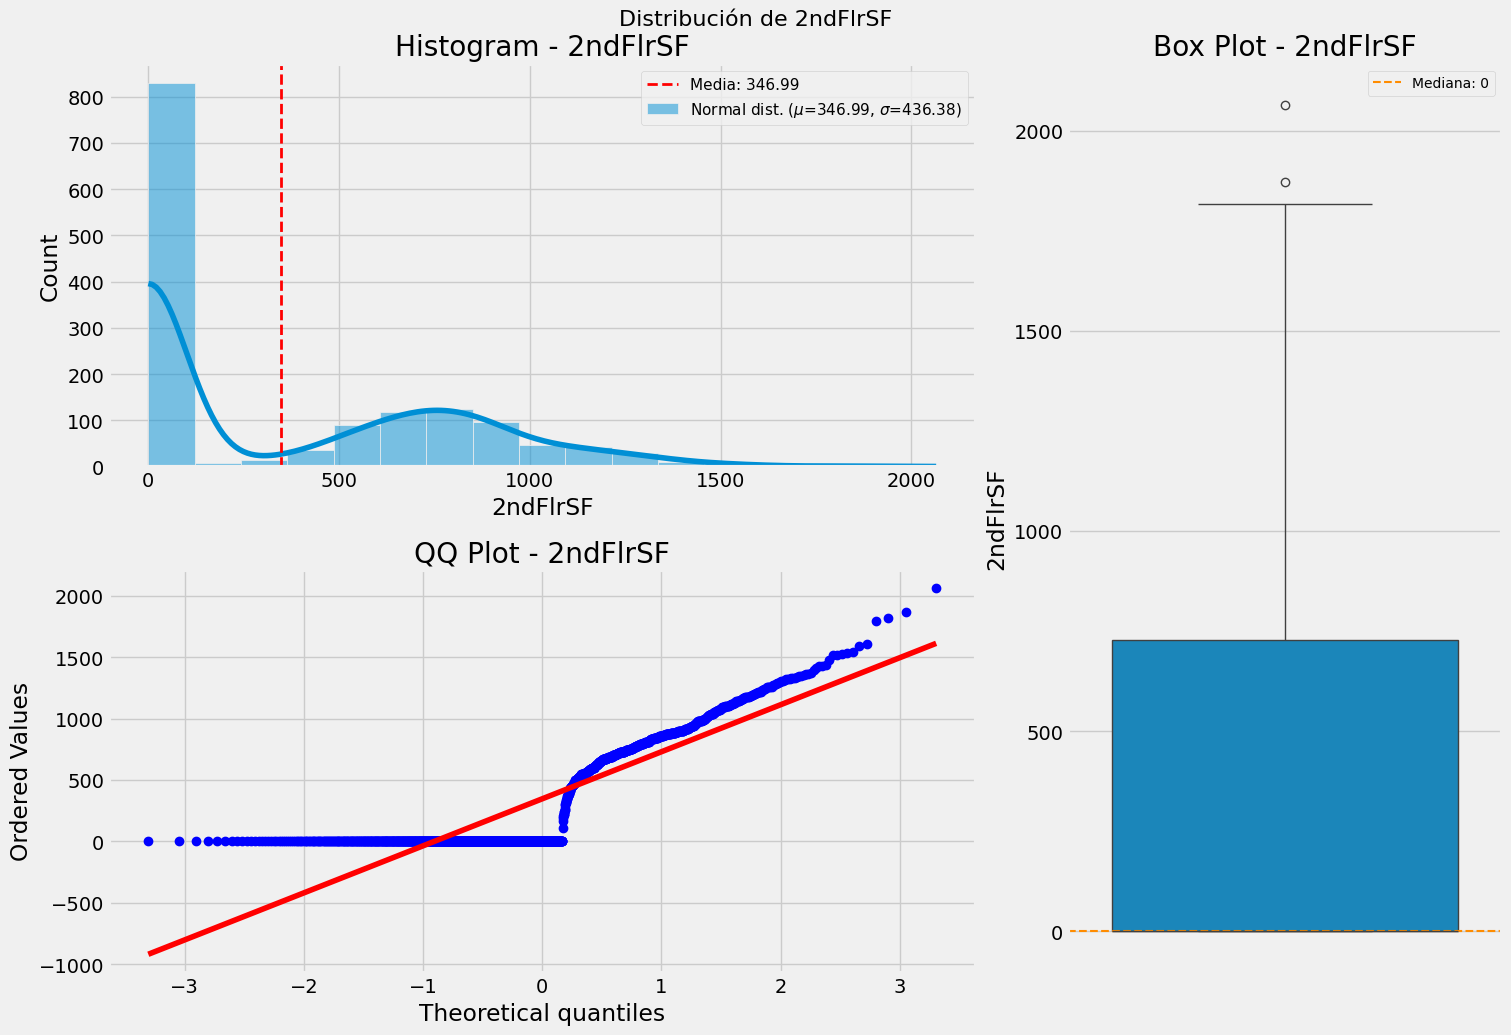

In [41]:
plot_dist_char(df, '2ndFlrSF')

# 2. Análisis Multivariado: Correlaciones y Heatmap

Se calcularán las correlaciones entre las variables numéricas del dataset y se visualizarán en un heatmap.

## Correlaciones

In [45]:
# Seleccionar solo variables numéricas
numeric_df = df.select_dtypes(include='number')

# Matriz de correlaciones
corr_matrix = numeric_df.corr()

# Top variables correlacionadas con SalePrice
print("=== Correlaciones de las variables con SalePrice ===")
print(corr_matrix['SalePrice'].sort_values(ascending=False))

=== Correlaciones de las variables con SalePrice ===
SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPor

## Heatmap de correlaciones

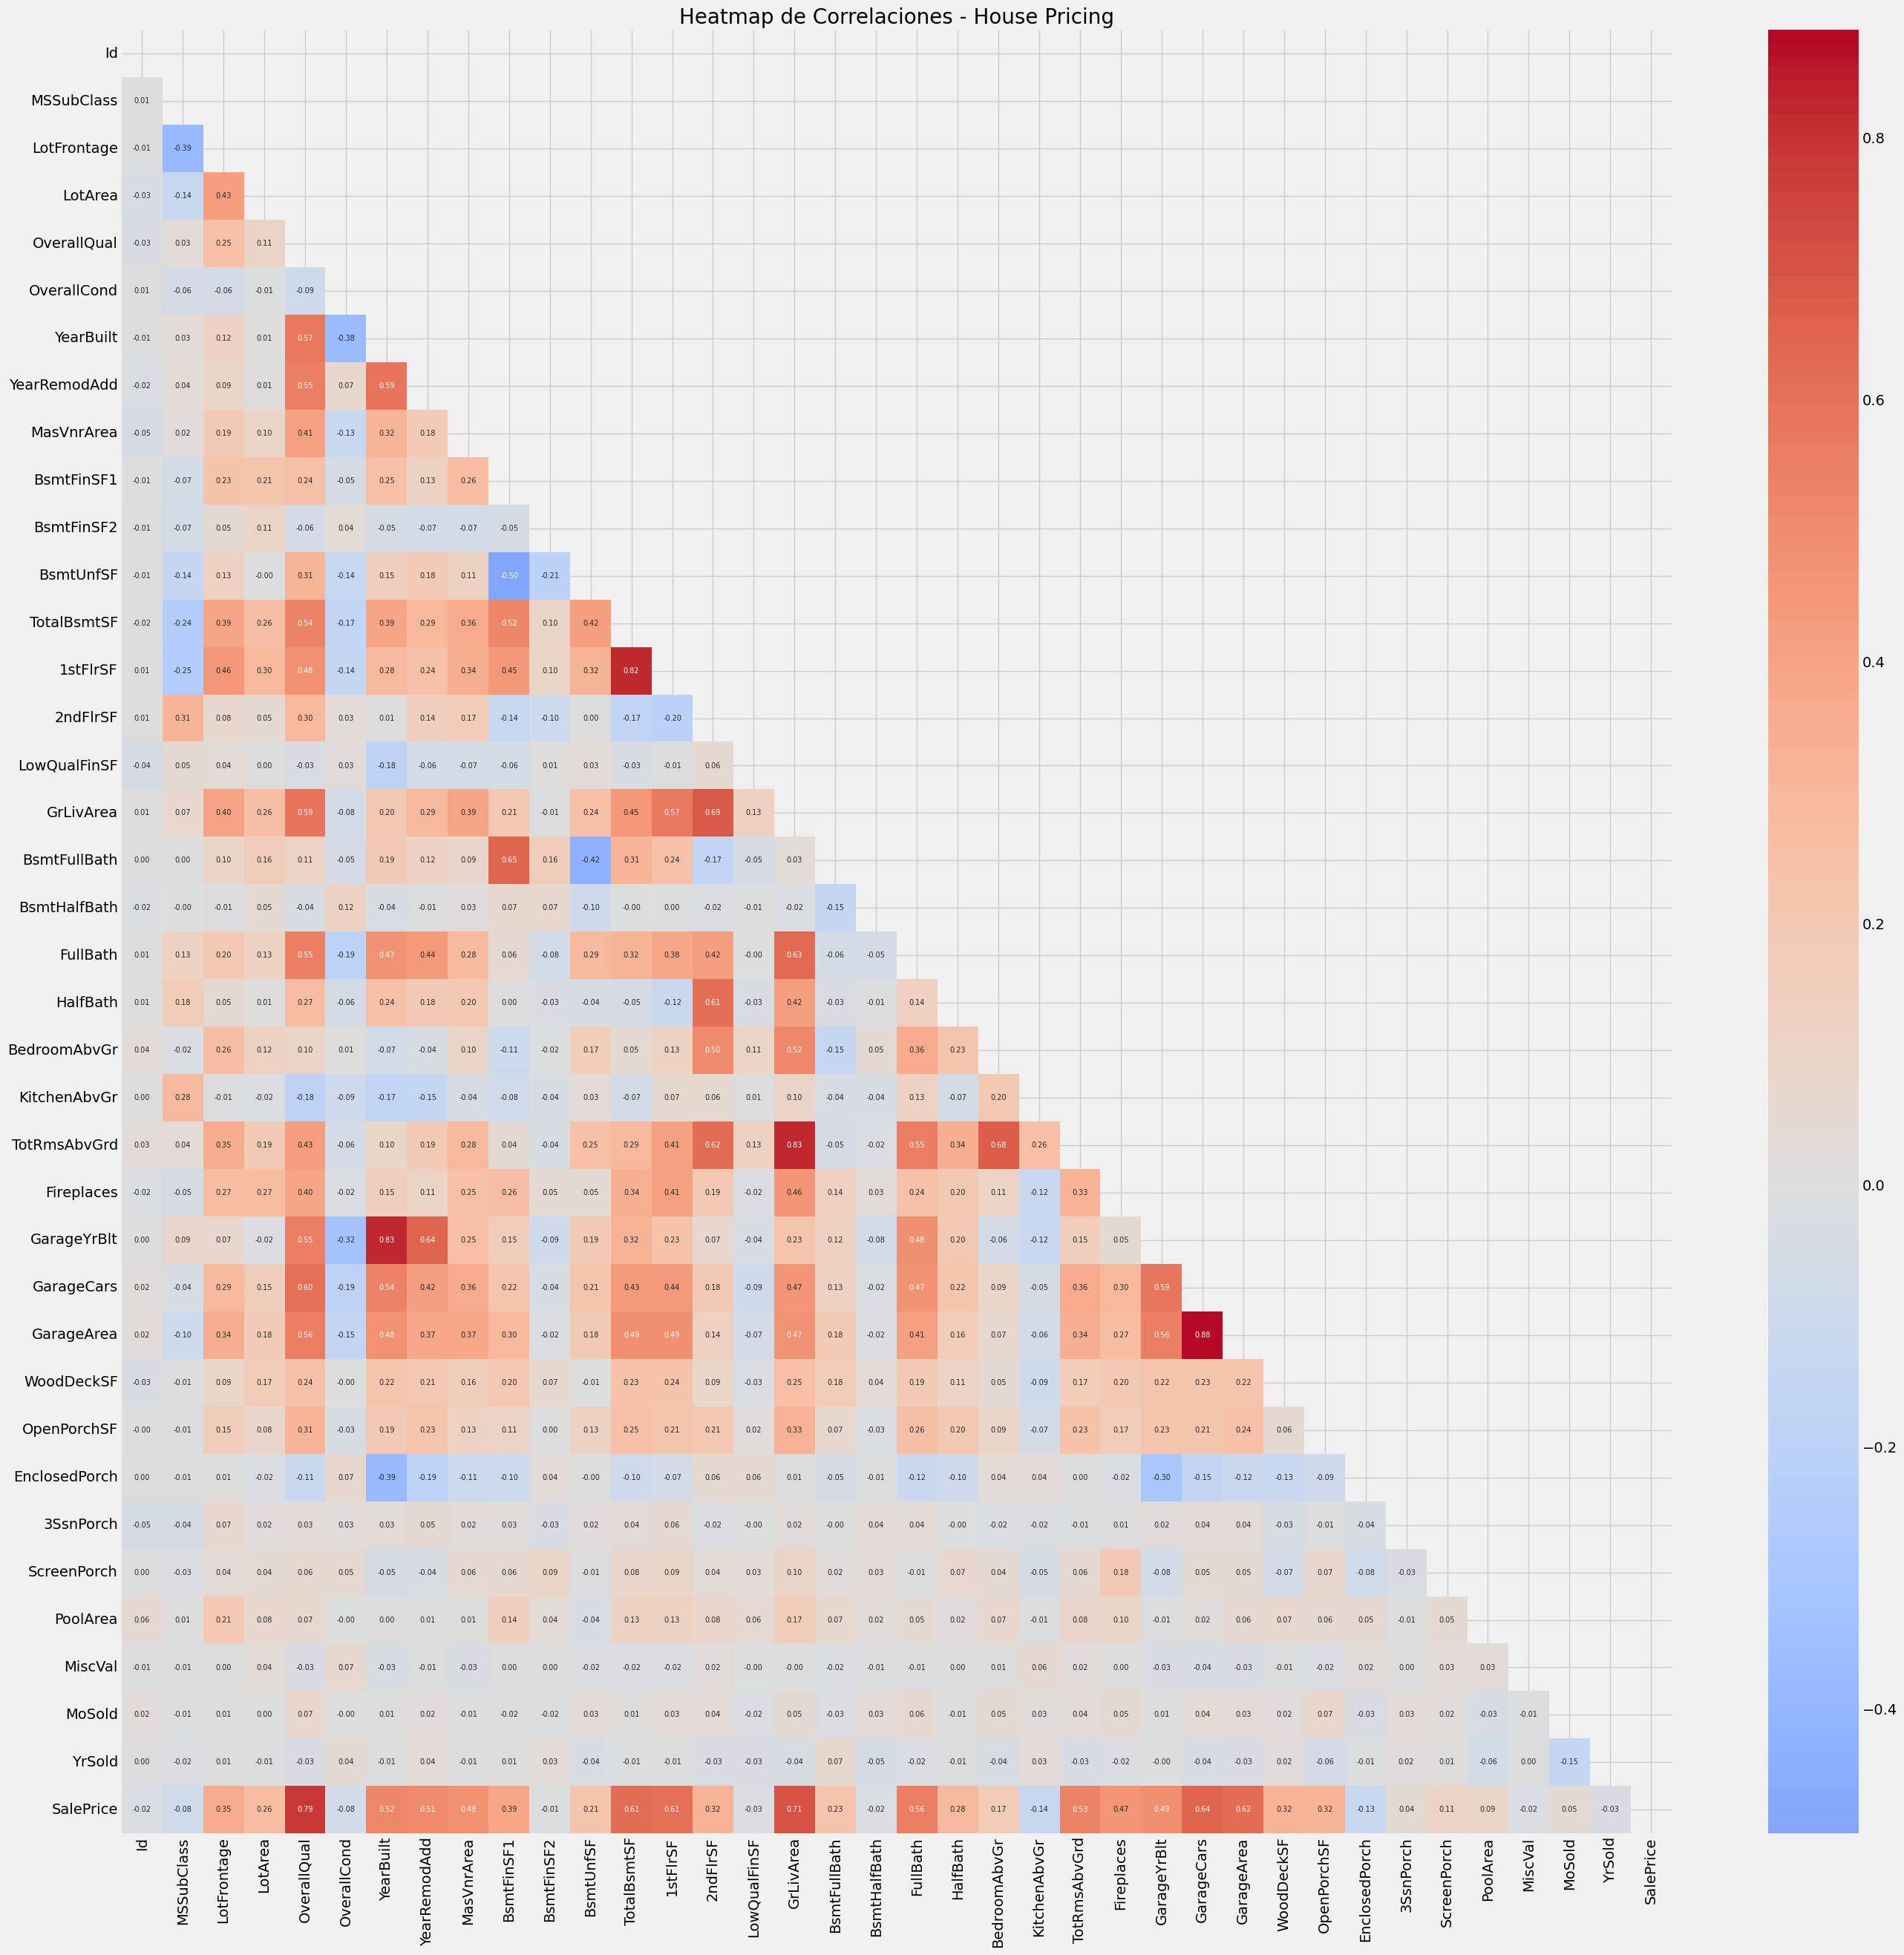

In [17]:
# Definir tamaño de la gráfica
f, ax = plt.subplots(figsize=(30, 30))

# Máscara para quitar la diagonal superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
sns.heatmap(corr_matrix,
            cmap=sns.color_palette('coolwarm', 200),
            mask=mask,
            annot=True,
            fmt='.2f',
            center=0,
            annot_kws={"size": 7})

plt.title("Heatmap de Correlaciones - House Pricing", fontsize=20)
plt.show()

# 3. Modelo de Regresión OLS con todas las variables numéricas

Se configurará un modelo OLS usando `statsmodels` con todas las variables numéricas para identificar cuáles son estadísticamente significativas (p-value < 0.05).

## Preparar datos y ajustar modelo OLS

In [52]:
# Seleccionar variables numéricas y eliminar filas con NaN
numeric_df = df.select_dtypes(include='number').dropna()

# Variable objetivo y variables predictoras
X = numeric_df.drop(['SalePrice', 'Id'], axis=1)
y = numeric_df['SalePrice']

# Agregar constante para el intercepto
X_const = sm.add_constant(X)

# Ajustar modelo OLS
est = sm.OLS(y, X_const).fit()

# Imprimir reporte
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.810
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     135.7
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        17:49:48   Log-Likelihood:                -13358.
No. Observations:                1121   AIC:                         2.679e+04
Df Residuals:                    1086   BIC:                         2.696e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3.232e+05    1.7e+06     -0.190

# 4. Multicolinealidad: Variance Inflation Factor (VIF)

Se calculará el VIF para detectar variables con alta multicolinealidad:

- VIF = inf → Multicolinealidad perfecta (relación matemática exacta)
- VIF > 10  → Alta multicolinealidad (problemática)
- VIF 5-10  → Multicolinealidad moderada (revisar)
- VIF < 5   → Aceptable

In [51]:
# Calcular VIF para cada variable
vif_data = pd.DataFrame()
vif_data['Feature'] = X_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# Quitar constante del reporte
vif_data = vif_data[vif_data['Feature'] != 'const']

# Ordenar por VIF descendente
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_data)

          Feature       VIF
0       BsmtUnfSF       inf
1    LowQualFinSF       inf
2       GrLivArea       inf
3      BsmtFinSF1       inf
4      BsmtFinSF2       inf
5     TotalBsmtSF       inf
6        1stFlrSF       inf
7        2ndFlrSF       inf
8       YearBuilt  6.093690
9    TotRmsAbvGrd  4.625789
10    GarageYrBlt  4.563375
11     GarageArea  4.441833
12     GarageCars  4.307530
13    OverallQual  3.449065
14       FullBath  3.118371
15   YearRemodAdd  2.744767
16   BedroomAbvGr  2.288242
17       HalfBath  2.268926
18   BsmtFullBath  2.215748
19    LotFrontage  1.827864
20    OverallCond  1.765052
21     MSSubClass  1.717512
22   KitchenAbvGr  1.592484
23     Fireplaces  1.585143
24     MasVnrArea  1.458798
25        LotArea  1.353675
26  EnclosedPorch  1.320675
27    OpenPorchSF  1.301864
28     WoodDeckSF  1.233511
29       PoolArea  1.192403
30   BsmtHalfBath  1.150956
31    ScreenPorch  1.150577
32        MiscVal  1.099964
33         MoSold  1.068200
34         YrSold  1

## Visualizar VIF

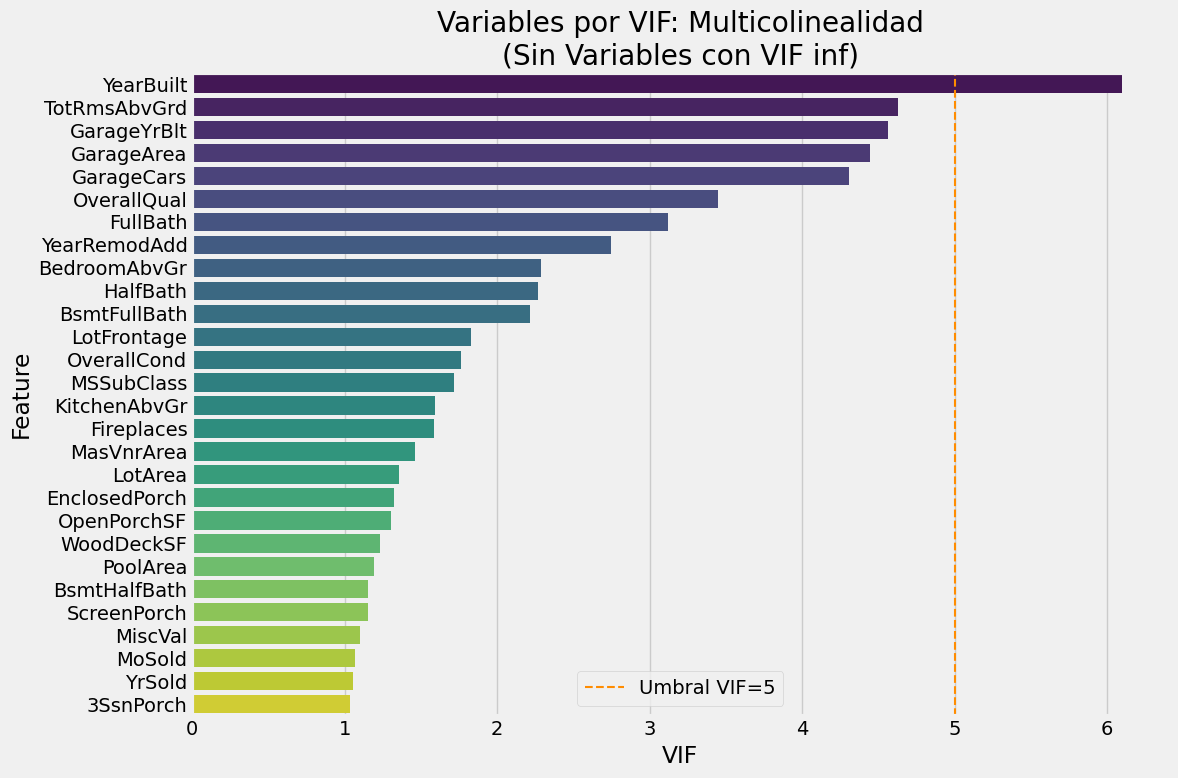

In [59]:
plt.figure(figsize=(12, 8))
sns.barplot(x='VIF', y='Feature', data=vif_data[8:36], palette='viridis')
plt.axvline(x=5, color='darkorange', linestyle='--', linewidth=1.5, label='Umbral VIF=5')
plt.title('Variables por VIF: Multicolinealidad\n(Sin Variables con VIF inf)')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Modelo de Regresión Final

Con base en el análisis OLS y VIF, se eliminan las variables:
- Con p-value > 0.05 (no significativas estadísticamente)
- Con VIF > 10 (alta multicolinealidad)

Criterios usados:

- ✅ Mantener → VIF < 5  AND  P>|t| < 0.05
- ⚠️ Mantener → VIF moderado (5-10) BUT P>|t| muy significativo (0.000)
- ❌ Eliminar → VIF = inf  (multicolinealidad perfecta)
- ❌ Eliminar → P>|t| > 0.05  (no significativa)
- ❌ Eliminar → VIF alto AND P>|t| > 0.05  (doble razón)

Se construye el modelo final y se mide su precisión con RMSE y R².

In [61]:
# Variables a eliminar por alta multicolinealidad o baja significancia
cols_to_drop = [
    'Id',

    # --- VIF = inf (multicolinealidad perfecta - grupo área habitable) ---
    # GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF
    # Se queda GrLivArea (más correlacionada con SalePrice)
    '1stFlrSF',          # VIF inf + P>|t| = 0.093
    '2ndFlrSF',          # VIF inf + P>|t| = 0.052
    'LowQualFinSF',      # VIF inf + P>|t| = 0.906

    # --- VIF = inf (multicolinealidad perfecta - grupo área sótano) ---
    # TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF
    # Se queda BsmtFinSF1 (más significativa, P>|t| = 0.002)
    'TotalBsmtSF',       # VIF inf + P>|t| = 0.069
    'BsmtFinSF2',        # VIF inf + P>|t| = 0.904
    'BsmtUnfSF',         # VIF inf + P>|t| = 0.361

    # --- VIF moderado + no significativas en OLS ---
    'GarageArea',        # VIF 4.44 + P>|t| = 0.592 (redundante con GarageCars)
    'GarageYrBlt',       # VIF 4.56 + P>|t| = 0.589
    'YearRemodAdd',      # VIF 2.74 + P>|t| = 0.164

    # --- No significativas en OLS (P>|t| > 0.05) ---
    'BsmtHalfBath',      # P>|t| = 0.623
    'FullBath',          # P>|t| = 0.127
    'HalfBath',          # P>|t| = 0.736
    'OpenPorchSF',       # P>|t| = 0.905
    'EnclosedPorch',     # P>|t| = 0.726
    '3SsnPorch',         # P>|t| = 0.357
    'MiscVal',           # P>|t| = 0.580
    'MoSold',            # P>|t| = 0.596
    'YrSold',            # P>|t| = 0.764
    'LotFrontage',       # P>|t| = 0.058 (borderline)
]

# Construir X final
X_final = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

print(f"Variables originales : {X.shape[1]}")
print(f"Variables finales    : {X_final.shape[1]}")
print(f"\nVariables en el modelo final:\n{list(X_final.columns)}")

# Reshape para sklearn
X_sk = X_final.values
y_sk = y.values

# Instanciar y entrenar modelo
reg = LinearRegression()
reg.fit(X_sk, y_sk)

# Predicciones
y_pred = reg.predict(X_sk)

# Métricas
rmse = np.sqrt(mean_squared_error(y_sk, y_pred))
r2 = reg.score(X_sk, y_sk)

print(f"\nR²   : {r2:.4f}")
print(f"RMSE : {rmse:.2f}")

Variables originales : 36
Variables finales    : 17

Variables en el modelo final:
['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'GrLivArea', 'BsmtFullBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'WoodDeckSF', 'ScreenPorch', 'PoolArea']

R²   : 0.8071
RMSE : 36441.80


## Análisis de Residuales del Modelo Final

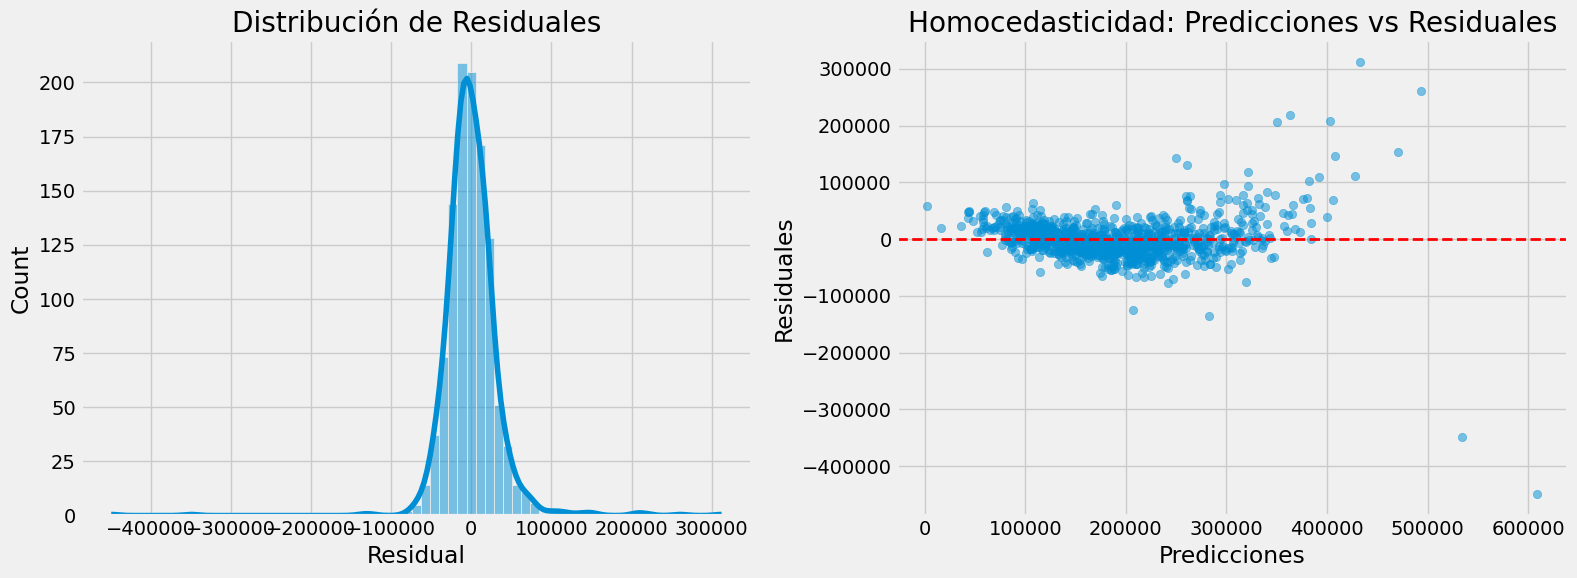

In [72]:
residual = y_sk - y_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución de residuales
sns.histplot(residual, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Residuales')
axes[0].set_xlabel('Residual')

# Homocedasticidad
axes[1].scatter(y_pred, residual, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Homocedasticidad: Predicciones vs Residuales')
axes[1].set_xlabel('Predicciones')
axes[1].set_ylabel('Residuales')

plt.tight_layout()
plt.show()

## QQ Plot de Residuales

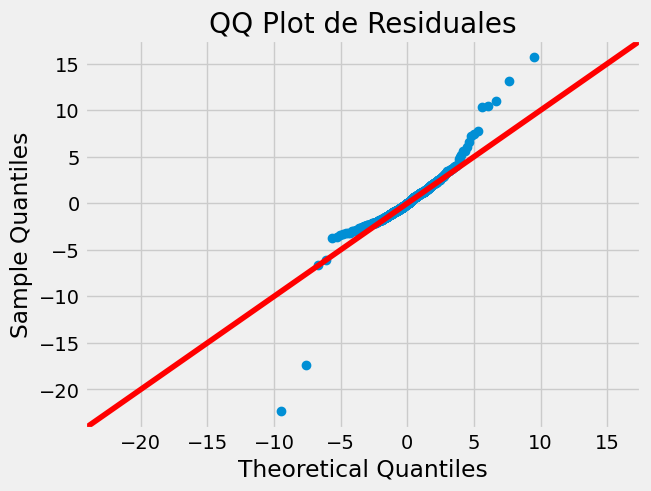

In [70]:
fig = sm.qqplot(residual, stats.t, fit=True, line='45')
plt.title('QQ Plot de Residuales')
plt.show()

# 6. Conclusiones

### Distribución de Variables
- **`SalePrice`**:
  Presenta sesgo positivo (right-skewed) con una media de \$180,921 y una desviación estándar de \$79,442.
  La mayoría de las casas se concentran entre \$129,975 (Q1) y \$214,000 (Q3), pero existen valores atípicos que alcanzan hasta \$755,000.
  El QQ Plot confirma la desviación de la normalidad en las colas.

- **`GrLivArea`**:
  También presenta sesgo positivo con una media de 1,515 ft² y desviación estándar de 525 ft².
  La distribución se aproxima más a la normal que `SalePrice`, aunque existen outliers superiores a 4,000 ft².
  La mediana (1,464) y la media (1,515) son cercanas, lo que indica un sesgo moderado.

- **`2ndFlrSF`**:
  Es la variable con distribución más atípica. El 50% de las observaciones tienen valor 0 (casas sin segundo piso),
  lo que genera una distribución bimodal. La mediana es 0 y la media es 347 ft², evidenciando el fuerte sesgo.
  El QQ Plot muestra una clara desviación de la normalidad.

### Correlaciones con SalePrice
Las variables con mayor correlación con el precio de venta son:
- `OverallQual` →  0.791 
- `GrLivArea`   →  0.709
- `GarageCars`  →  0.640 
- `GarageArea`  →  0.623 
- `TotalBsmtSF` →  0.614 

Estas variables explican gran parte de la variabilidad en el precio. Por otro lado, variables como `MSSubClass`, `OverallCond`, `EnclosedPorch` y `KitchenAbvGr` presentan correlación negativa con `SalePrice`.

### Significancia Estadística (OLS)
El modelo OLS inicial con todas las variables numéricas alcanzó un **R² = 0.810**, indicando que el modelo explica el 81% de la variabilidad del precio. Sin embargo, varias variables resultaron no significativas (P>|t| > 0.05), incluyendo:
`YearRemodAdd`, `BsmtFinSF2`, `BsmtUnfSF`, `BsmtHalfBath`, `FullBath`, `HalfBath`, `GarageYrBlt`, `GarageArea`, `OpenPorchSF`, `EnclosedPorch`, `3SsnPorch`, `MiscVal`, `MoSold` y `YrSold`.

### Multicolinealidad (VIF)
Se identificaron dos grupos de variables con **multicolinealidad perfecta (VIF = inf)**:
- **Grupo área habitable**: `GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF`
- **Grupo área sótano**: `TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF`

Adicionalmente, `YearBuilt` presentó VIF = 6.09 (moderado), pero se mantuvo en el modelo por su alta significancia estadística (P>|t| = 0.000).

### Modelo Final
Tras eliminar variables con multicolinealidad perfecta y baja significancia, el modelo final quedó con **17 variables** de las 36 originales:

Un **R² = 0.807** indica que el modelo explica el **80.7% de la variabilidad** en el precio de venta, lo cual representa un buen nivel de ajuste. 
El **RMSE de \$36,441** indica que, en promedio, las predicciones del modelo se desvían ~\$36,441 del precio real.

### Supuestos del Modelo
- **Normalidad de residuales**: El QQ Plot de residuales muestra que se aproximan a la normalidad en el centro,
  pero presentan desviaciones en las colas, especialmente por la presencia de outliers.
- **Homocedasticidad**: El gráfico de Predicciones vs Residuales muestra un patrón de dispersión creciente (heterocedasticidad),
  lo que sugiere que el modelo tiene mayor error de predicción para casas de precio más alto.